## 第3章

課題
公立中学校のクラス編成を行いたい。クラスは8つ、生徒数は318人  
要件  
１、学年の全生徒をそれぞれ１つのクラスに割り当てる  
２、各クラスの生徒の人数は39人以上40人以下  
３、各クラスの男子生徒、女子生徒はそれぞれ20人以下  
４、各クラスの学力試験の平均点は学年平均点の±10点まで  
５、各クラスにリーダー気質の生徒を2人以上割り当てる  
６、特別な支援が必要な生徒は各クラスに１人以下  
７、特定ペアの生徒はどういうクラスに割り当てない  

In [1]:
import pandas as pd

In [2]:
s_df = pd.read_csv("/Users/yoshikawahiroshi/projects/python-projects/data/raw/PyOptBook/3.school/students.csv")
len(s_df)

318

In [3]:
s_df.head()

,student_id,gender,leader_flag,support_flag,score
0,1,0,0,0,335
1,2,1,0,0,379
2,3,0,0,0,350
3,4,0,0,0,301
4,5,1,0,0,317


In [4]:
s_df["support_flag"].sum().item()

4

In [5]:
#生徒番号がユニークかどうか確認する
set(range(1,319)) == set(s_df["student_id"])

True

In [6]:
#男女の人数確認
s_df["gender"].value_counts()

gender
0    160
1    158
Name: count, dtype: int64

In [7]:
#成績の統計量チェック
s_df["score"].describe()

count    318.000000
mean     303.644654
std       65.179995
min       88.000000
25%      261.000000
50%      310.000000
75%      350.000000
max      485.000000
Name: score, dtype: float64

<Axes: >

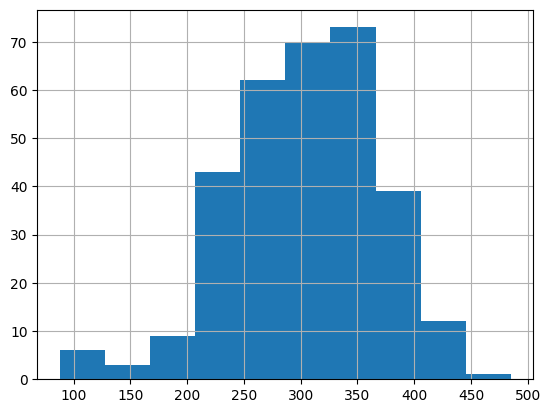

In [8]:
s_df["score"].hist()

In [9]:
s_pair_df = pd.read_csv("/Users/yoshikawahiroshi/projects/python-projects/data/raw/PyOptBook/3.school/student_pairs.csv")

In [10]:
s_pair_df

,student_id1,student_id2
0,118,189
1,72,50
2,314,233


In [11]:
## 数理モデリング
import pulp

### 要件の数式化

生徒のリストをS、クラスのリストをC、生徒ペアのリストをSSとする  

１、学年の全生徒をそれぞれ１つのクラスに割り当てる  
$$  \sum_{c\in{C}}x_{s,c} = 1  $$
２、各クラスの生徒の人数は39人以上40人以下  
$$  \sum_{s\in{S}}x_{s,c} \ge 39 $$
$$  \sum_{s\in{S}}x_{s,c} \le 40 $$

３、各クラスの男子生徒、女子生徒はそれぞれ20人以下  
$$  \sum_{s\in{S_{male}}}x_{s,c} \le 20 $$
$$  \sum_{s\in{S_{female}}}x_{s,c} \le 20 $$

４、各クラスの学力試験の平均点は学年平均点の±10点まで（線形問題になるように通分している）  
$$  (ScoreMean -10)・\sum_{s\in{S}}x_{s,c} \le \sum_{s\in{{S}}}score_{s}・X_{s,c} $$

５、各クラスにリーダー気質の生徒を2人以上割り当てる  
$$  \sum_{s\in{S_{leader}}}x_{s,c} \ge 2 $$

６、特別な支援が必要な生徒は各クラスに１人以下  
$$  \sum_{s\in{S_{supp}}}x_{s,c} \le 1 $$

７、特定ペアの生徒はどういうクラスに割り当てない  
$$  x_{s1,c} + x_{s2,c} \le 2 \quad c\in_{C}, (s1,s2)\in SS $$

In [89]:
# インスタンス作成
import pulp
import highspy

prob = pulp.LpProblem("Student_Pairing ", pulp.LpMaximize)

## 要件の実装
S = s_df["student_id"].tolist()
C = ["A","B","C","D","E","F","G","H"]
SC = [(s,c) for s in S for c in C]

# 決定変数の定義
x = pulp.LpVariable.dicts("x", SC, cat="Binary")

# １、学年の全生徒をそれぞれ１つのクラスに割り当てる
for s in S:
    prob += pulp.lpSum(x[s,c] for c in C) == 1

# ２、各クラスの生徒の人数は39人以上40人以下  
for c in C:
    prob += pulp.lpSum([x[s,c] for s in S]) >= 39
    prob += pulp.lpSum([x[s,c] for s in S]) <= 40

# ３、各クラスの男子生徒、女子生徒はそれぞれ20人以下  
S_male = s_df[s_df.gender == 1]["student_id"].tolist()
S_female = s_df[s_df.gender == 0]["student_id"].tolist()

for c in C:
    prob += pulp.lpSum([x[s,c] for s in S_male]) <= 20
    prob += pulp.lpSum([x[s,c] for s in S_female]) <= 20

# ４、各クラスの学力試験の平均点は学年平均点の±10点まで  
score = s_df.set_index("student_id")["score"].to_dict()
score_mean = s_df["score"].mean()

for c in C:
    prob += pulp.lpSum([x[s,c]*score[s] for s in S]) >= (score_mean - 10) * pulp.lpSum([x[s,c] for s in S])
    prob += pulp.lpSum([x[s,c]*score[s] for s in S]) <= (score_mean + 10) * pulp.lpSum([x[s,c] for s in S])

# ５、各クラスにリーダー気質の生徒を2人以上割り当てる  
leaders = s_df[s_df.leader_flag == 1]["student_id"].tolist()
for c in C:
    prob += pulp.lpSum([x[s,c] for s in leaders]) >= 2

# ６、特別な支援が必要な生徒は各クラスに１人以下  
support_needed = s_df[s_df.support_flag == 1]["student_id"].tolist()
for c in C:
    prob += pulp.lpSum([x[s,c] for s in support_needed]) <= 1 

# ７、特定ペアの生徒はどういうクラスに割り当てない  
SS = [(row.student_id1, row.student_id2) for row in s_pair_df.itertuples()]

for s1, s2 in SS:
    for c in C:
        prob += x[s1,c] + x[s2,c] <= 1

/Users/yoshikawahiroshi/projects/python-projects/.venv/lib/python3.12/site-packages/pulp/pulp.py:1298: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")


In [90]:
from pulp.apis import HiGHS
solver = HiGHS(msg=True)

status = prob.solve(solver)
print(f"Status: {pulp.LpStatus[status]}")
print(pulp.LpStatus[status])


Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
MIP has 406 rows; 2545 cols; 15480 nonzeros; 2544 integer variables (2544 binary)
Coefficient ranges:
  Matrix  [4e-01, 2e+02]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 4e+01]
Presolving model
406 rows, 2544 cols, 15480 nonzeros 0s
398 rows, 2544 cols, 12936 nonzeros 0s
Presolve reductions: rows 398(-8); columns 2544(-1); nonzeros 12936(-2544) 
Objective function is integral with scale 1

Solving MIP model with:
   398 rows
   2544 cols (2544 binary, 0 integer, 0 implied int., 0 continuous, 0 domain fixed)
   12936 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper;

In [92]:
# 結果表示
C2Ss = {}
for c in C:
    C2Ss[c] = [s for s in S if pulp.value(x[s,c]) == 1]

for c, Ss in C2Ss.items():
    print("class", c)
    print("Num", len(Ss))
    print("Student", Ss)
    print()

class A
Num 40
Student [8, 10, 26, 40, 41, 48, 51, 75, 91, 104, 110, 112, 117, 119, 120, 126, 139, 143, 157, 160, 161, 171, 173, 175, 179, 182, 188, 191, 196, 200, 203, 232, 252, 253, 267, 268, 288, 298, 300, 307]

class B
Num 39
Student [18, 21, 30, 39, 50, 56, 59, 70, 74, 79, 86, 89, 101, 118, 130, 140, 153, 154, 159, 163, 185, 197, 199, 201, 206, 210, 211, 218, 223, 226, 243, 246, 265, 270, 290, 299, 302, 310, 317]

class C
Num 40
Student [1, 4, 6, 13, 25, 32, 37, 52, 73, 81, 84, 87, 94, 99, 102, 121, 123, 136, 152, 156, 176, 183, 187, 189, 190, 192, 214, 224, 233, 234, 236, 245, 255, 262, 273, 283, 289, 297, 304, 316]

class D
Num 40
Student [3, 9, 22, 24, 28, 46, 49, 53, 55, 57, 61, 62, 63, 93, 106, 107, 131, 138, 149, 162, 164, 165, 167, 174, 209, 213, 219, 238, 242, 247, 251, 256, 257, 269, 274, 286, 291, 295, 312, 314]

class E
Num 40
Student [5, 17, 20, 23, 34, 42, 44, 47, 65, 67, 77, 78, 85, 88, 97, 98, 109, 114, 115, 125, 132, 141, 144, 150, 168, 178, 205, 231, 235, 237, 239

In [93]:
## 検証

# 割り当てられたクラスを元データに付加
result_df = s_df.copy()
S2C = {s:c for s in S for c in C if x[s,c].value() == 1}
result_df["class"] = result_df["student_id"].map(S2C)
result_df.head()

,student_id,gender,leader_flag,support_flag,score,class
0,1,0,0,0,335,C
1,2,1,0,0,379,G
2,3,0,0,0,350,D
3,4,0,0,0,301,C
4,5,1,0,0,317,E


In [95]:
result_df["class"].value_counts().sort_index()

class
A    40
B    39
C    40
D    40
E    40
F    39
G    40
H    40
Name: count, dtype: int64

In [97]:
# 人数やスコアに「棒グラフ」のような色をつけて視覚化
result_df.groupby("class")["score"].mean().to_frame().style.bar(color="gray")

,score
class,
A,301.650000
B,309.974359
C,294.200000
D,300.450000
E,304.950000
F,307.692308
G,309.175000
H,301.325000


In [99]:
# リーダーの人数
result_df.groupby("class")["leader_flag"].sum().to_frame().style.bar(color="gray")

,leader_flag
class,
A,2
B,2
C,2
D,2
E,2
F,2
G,3
H,2


In [103]:
# 要支援者の人数
result_df.groupby("class")["support_flag"].sum().to_frame().style.bar(color="gray")

,support_flag
class,
A,0
B,0
C,0
D,0
E,1
F,1
G,1
H,1


In [104]:
for i, (s1, s2) in enumerate(SS):
    print("case:",i)
    c1 = S2C[s1]
    c2 = S2C[s2]
    print("s1:{}-{}".format(s1, c1))
    print("s2:{}-{}".format(s2, c2))

case: 0
s1:118-B
s2:189-C
case: 1
s1:72-H
s2:50-B
case: 2
s1:314-D
s2:233-C


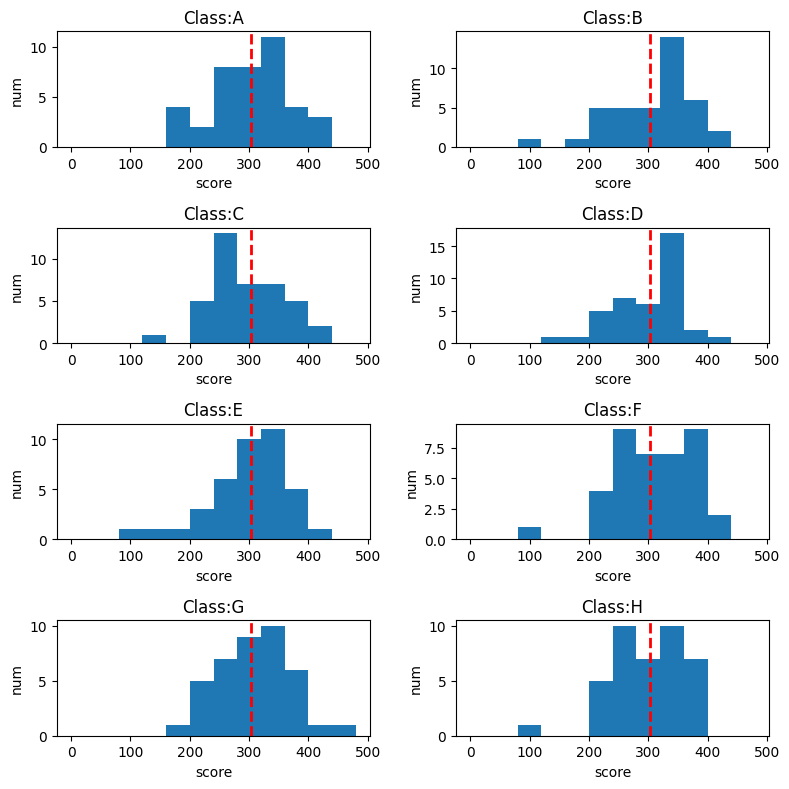

In [149]:
# 学力の分布を見てみよう
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,8))
for i, c in enumerate(C):
    cls_df = result_df[result_df['class'] == c]
    ax = fig.add_subplot(4, 2, i+1, xlabel="score", ylabel="num")
    ax.axvline(x=score_mean, color='red', linestyle='--', linewidth=2)
    title = "Class:{:s}".format(c)
    ax.set_title(title)
    fig.tight_layout()
    ax.hist(cls_df["score"], bins = range(0,500,40))

In [ ]:
# 学力の偏りをなくしてみる

# 学力順位を生成
s_df["score_rank"] = s_df["score"].rank(ascending=False, method="first") # 降順で、同位を許さない

# 学力順にクラス編成し、init_assigned_classを生成
## クラス割当を計算できるようにするための辞書を作成
class_dic = {0:"A", 1:"B", 2:"C", 3:"D", 4:"E", 5:"F", 6:"G", 7:"H"}
## 学力順位を8で割った余りをクラスにマッピングして、初期割当クラスを生成
s_df["init_assinged_class"] = s_df["score_rank"].map(lambda x:x % 8).map(class_dic) # 学力順位を8で割って、その余りで割当クラスを決めている

# 初期割当クラスのフラグ作成
init_flag = {(s, c):0 for s in S for c in C} # 全ての生徒とクラスの組み合わせに対して、初期割当フラグを0で初期化
for row in s_df.itertuples():                # 学生ごとに、初期割当クラスのフラグを1にする
    init_flag[row.student_id, row.init_assinged_class] = 1

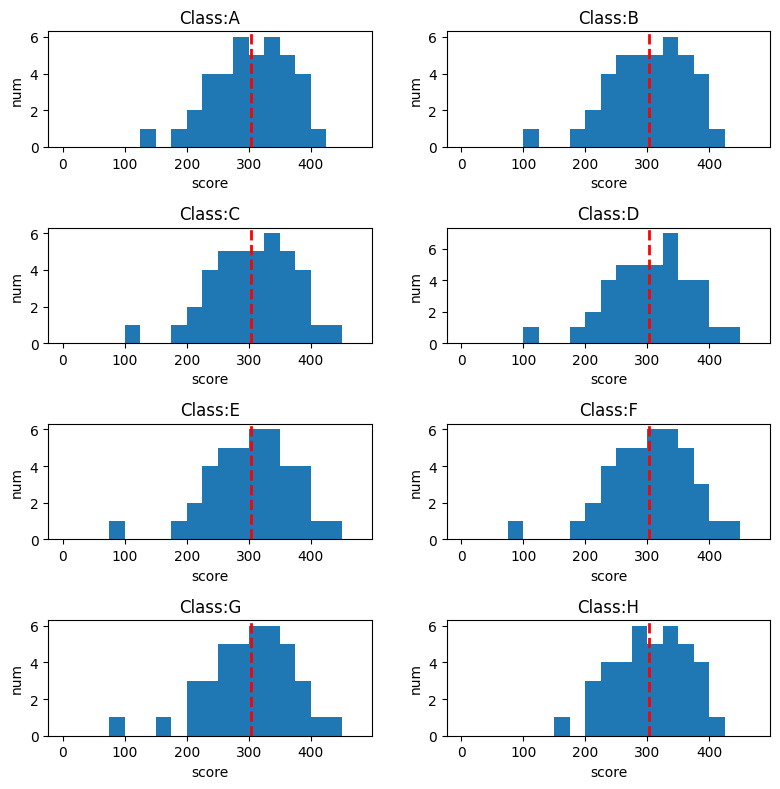

In [121]:
# 学力順位でのクラス配置における学力分布をチェック
fig = plt.figure(figsize=(8,8))
for i, c in enumerate(C):
    cls_df = result_df[s_df['init_assinged_class'] == c]
    ax = fig.add_subplot(4, 2, i+1, xlabel="score", ylabel="num")
    ax.axvline(x=score_mean, color='red', linestyle='--', linewidth=2)
    title = "Class:{:s}".format(c)
    ax.set_title(title)
    fig.tight_layout()
    ax.hist(cls_df["score"], bins = range(0,500,25))

In [150]:
# 初期配置クラスを使って最適化してみる

prob = pulp.LpProblem("Student_Pairing ", pulp.LpMaximize)

## 要件の実装
S = s_df["student_id"].tolist()
C = ["A","B","C","D","E","F","G","H"]
SC = [(s,c) for s in S for c in C]

# 決定変数の定義
x = pulp.LpVariable.dicts("x", SC, cat="Binary")

# １、学年の全生徒をそれぞれ１つのクラスに割り当てる
for s in S:
    prob += pulp.lpSum(x[s,c] for c in C) == 1

# ２、各クラスの生徒の人数は39人以上40人以下  
for c in C:
    prob += pulp.lpSum([x[s,c] for s in S]) >= 39
    prob += pulp.lpSum([x[s,c] for s in S]) <= 40

# ３、各クラスの男子生徒、女子生徒はそれぞれ20人以下  
S_male = s_df[s_df.gender == 1]["student_id"].tolist()
S_female = s_df[s_df.gender == 0]["student_id"].tolist()

for c in C:
    prob += pulp.lpSum([x[s,c] for s in S_male]) <= 20
    prob += pulp.lpSum([x[s,c] for s in S_female]) <= 20

# ４、各クラスの学力試験の平均点は学年平均点の±10点まで  
score = s_df.set_index("student_id")["score"].to_dict()
score_mean = s_df["score"].mean()

for c in C:
    prob += pulp.lpSum([x[s,c]*score[s] for s in S]) >= (score_mean - 10) * pulp.lpSum([x[s,c] for s in S])
    prob += pulp.lpSum([x[s,c]*score[s] for s in S]) <= (score_mean + 10) * pulp.lpSum([x[s,c] for s in S])

# ５、各クラスにリーダー気質の生徒を2人以上割り当てる  
leaders = s_df[s_df.leader_flag == 1]["student_id"].tolist()
for c in C:
    prob += pulp.lpSum([x[s,c] for s in leaders]) >= 2

# ６、特別な支援が必要な生徒は各クラスに１人以下  
support_needed = s_df[s_df.support_flag == 1]["student_id"].tolist()
for c in C:
    prob += pulp.lpSum([x[s,c] for s in support_needed]) <= 1 

# ７、特定ペアの生徒はどういうクラスに割り当てない  
SS = [(row.student_id1, row.student_id2) for row in s_pair_df.itertuples()]

for s1, s2 in SS:
    for c in C:
        prob += x[s1,c] + x[s2,c] <= 1

# ８、初期配置クラスをなるべく変えないようにする
init_list = [ac for ac, value in init_flag.items() if value == 1]
prob += pulp.lpSum([x[s, c] for s, c in init_list])  # init_flagと配置後のクラスの掛け算が最大になる=初期クラスからあまり変わっていない

# prob += pulp.lpSum([x[s, c] * init_flag[s,c] for s in S for c in C])  # 初期配置クラスのフラグと配置後のクラスの掛け算が最大になる=初期クラスからあまり変わっていない

/Users/yoshikawahiroshi/projects/python-projects/.venv/lib/python3.12/site-packages/pulp/pulp.py:1298: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")


In [151]:
from pulp.apis import HiGHS
solver = HiGHS(msg=True)

status = prob.solve(solver)
print(f"Status: {pulp.LpStatus[status]}")
print(pulp.LpStatus[status])


Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
MIP has 406 rows; 2544 cols; 15480 nonzeros; 2544 integer variables (2544 binary)
Coefficient ranges:
  Matrix  [4e-01, 2e+02]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 4e+01]
Presolving model
406 rows, 2544 cols, 15480 nonzeros 0s
398 rows, 2544 cols, 12936 nonzeros 0s
Presolve reductions: rows 398(-8); columns 2544(-0); nonzeros 12936(-2544) 
Objective function is integral with scale 1

Solving MIP model with:
   398 rows
   2544 cols (2544 binary, 0 integer, 0 implied int., 0 continuous, 0 domain fixed)
   12936 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper;

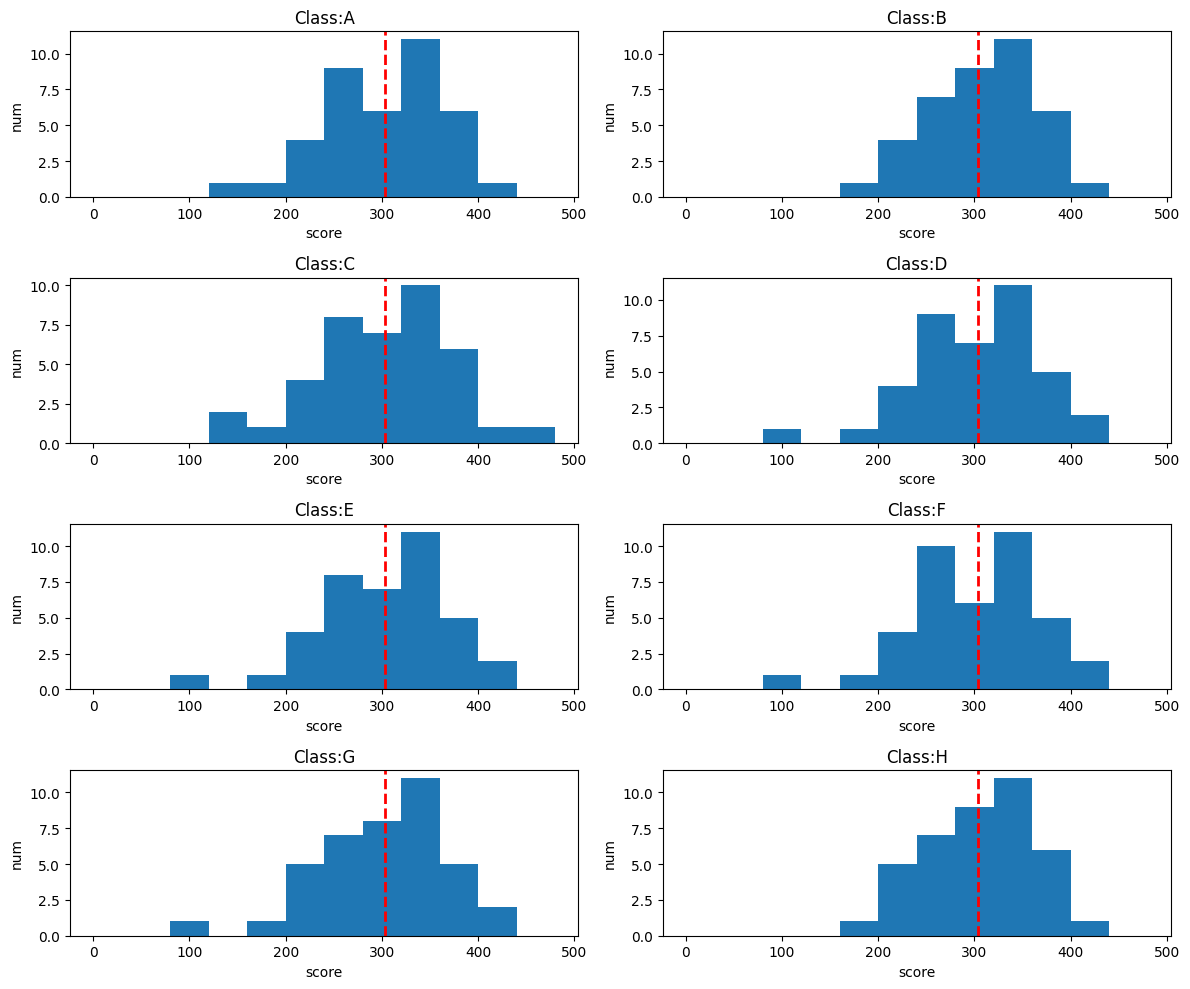

In [152]:
## 検証

# 割り当てられたクラスを元データに付加
result2_df = s_df.copy()
S2C = {s:c for s in S for c in C if x[s,c].value() == 1}
result2_df["class"] = result2_df["student_id"].map(S2C)

fig = plt.figure(figsize=(12,10))
for i, c in enumerate(C):
    cls_df = result2_df[result2_df['class'] == c]
    ax = fig.add_subplot(4, 2, i+1, xlabel="score", ylabel="num")
    ax.axvline(x=score_mean, color='red', linestyle='--', linewidth=2)
    title = "Class:{:s}".format(c)
    ax.set_title(title)
    fig.tight_layout()
    ax.hist(cls_df["score"], bins = range(0,500,40))
